**Business Problem**

Hospital readmissions increase healthcare costs and place additional pressure
 on hospital resources predicting readmission risk can help improve
patient care and reduce avoidable readmissions.

**Objective**

Build a machine learning model to predict whether a patient is likely to be readmitted using healthcare and hospital visit data.

**1: Data Understanding**

In [60]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [15]:
# Load the CSV file
df= pd.read_csv("hospital_readmission.csv")

In [16]:
df.shape

(25000, 65)

In [17]:
df.columns

Index(['time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'number_diagnoses', 'race_Caucasian',
       'race_AfricanAmerican', 'gender_Female', 'age_[70-80)', 'age_[60-70)',
       'age_[50-60)', 'age_[80-90)', 'age_[40-50)', 'payer_code_?',
       'payer_code_MC', 'payer_code_HM', 'payer_code_SP', 'payer_code_BC',
       'medical_specialty_?', 'medical_specialty_InternalMedicine',
       'medical_specialty_Emergency/Trauma',
       'medical_specialty_Family/GeneralPractice',
       'medical_specialty_Cardiology', 'diag_1_428', 'diag_1_414',
       'diag_1_786', 'diag_2_276', 'diag_2_428', 'diag_2_250', 'diag_2_427',
       'diag_3_250', 'diag_3_401', 'diag_3_276', 'diag_3_428',
       'max_glu_serum_None', 'A1Cresult_None', 'metformin_No',
       'repaglinide_No', 'nateglinide_No', 'chlorpropamide_No',
       'glimepiride_No', 'acetohexamide_No', 'glipizide_No', 'glyburide_No',
     

In [18]:
df.dtypes

,0
time_in_hospital,int64
num_lab_procedures,int64
num_procedures,int64
num_medications,int64
number_outpatient,int64
...,...
metformin-rosiglitazone_No,bool
metformin-pioglitazone_No,bool
change_No,bool
diabetesMed_Yes,bool


In [19]:
df.head()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,race_Caucasian,race_AfricanAmerican,...,citoglipton_No,insulin_No,glyburide-metformin_No,glipizide-metformin_No,glimepiride-pioglitazone_No,metformin-rosiglitazone_No,metformin-pioglitazone_No,change_No,diabetesMed_Yes,readmitted
0,14,41,0,11,0,0,0,6,True,False,...,True,True,True,True,True,True,True,True,True,0
1,2,30,0,12,0,0,1,9,True,False,...,True,False,True,True,True,True,True,False,True,1
2,5,66,0,22,1,0,2,9,True,False,...,True,True,True,True,True,True,True,True,True,1
3,3,63,0,8,0,0,0,8,True,False,...,True,True,True,True,True,True,True,True,True,1
4,5,40,0,6,0,0,1,9,True,False,...,True,True,True,True,True,True,True,True,False,0


In [20]:
df.tail()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,race_Caucasian,race_AfricanAmerican,...,citoglipton_No,insulin_No,glyburide-metformin_No,glipizide-metformin_No,glimepiride-pioglitazone_No,metformin-rosiglitazone_No,metformin-pioglitazone_No,change_No,diabetesMed_Yes,readmitted
24995,2,85,0,12,0,0,0,9,True,False,...,True,False,True,True,True,True,True,False,True,0
24996,5,35,2,15,0,0,0,9,False,True,...,True,True,True,True,True,True,True,True,True,1
24997,3,10,1,23,1,0,0,4,True,False,...,True,False,True,True,True,True,True,False,True,1
24998,8,69,3,41,1,0,0,9,True,False,...,True,True,False,True,True,True,True,False,True,1
24999,3,48,1,17,0,0,0,9,True,False,...,True,True,True,True,True,True,True,True,False,0


In [21]:
df.isnull().sum()

,0
time_in_hospital,0
num_lab_procedures,0
num_procedures,0
num_medications,0
number_outpatient,0
...,...
metformin-rosiglitazone_No,0
metformin-pioglitazone_No,0
change_No,0
diabetesMed_Yes,0


In [29]:
# Checking duplicate rows
df.duplicated().sum()

np.int64(0)

In [23]:
# Summary statistics
df.describe()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted
count,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000
mean,4.395640,42.96012,1.341080,15.988440,0.365920,0.203280,0.64300,7.420160,0.456400
std,2.991165,19.76881,1.705398,8.107743,1.224419,0.982973,1.26286,1.940932,0.498105
min,1.000000,1.00000,0.000000,1.000000,0.000000,0.000000,0.00000,1.000000,0.000000
25%,2.000000,31.00000,0.000000,10.000000,0.000000,0.000000,0.00000,6.000000,0.000000
50%,4.000000,44.00000,1.000000,15.000000,0.000000,0.000000,0.00000,8.000000,0.000000
75%,6.000000,57.00000,2.000000,20.000000,0.000000,0.000000,1.00000,9.000000,1.000000
max,14.000000,126.00000,6.000000,81.000000,36.000000,64.000000,21.00000,16.000000,1.000000


In [24]:
# Unique values
df.nunique()

,0
time_in_hospital,14
num_lab_procedures,108
num_procedures,7
num_medications,71
number_outpatient,27
...,...
metformin-rosiglitazone_No,1
metformin-pioglitazone_No,1
change_No,2
diabetesMed_Yes,2


**2: Missing Values Analysis**

In [25]:
# Missing values
missing_values = df.isnull().sum()

missing_values

,0
time_in_hospital,0
num_lab_procedures,0
num_procedures,0
num_medications,0
number_outpatient,0
...,...
metformin-rosiglitazone_No,0
metformin-pioglitazone_No,0
change_No,0
diabetesMed_Yes,0


In [26]:
# Calculate missing percentage
missing_percentage = (missing_values / len(df)) * 100

missing_percentage

,0
time_in_hospital,0.0
num_lab_procedures,0.0
num_procedures,0.0
num_medications,0.0
number_outpatient,0.0
...,...
metformin-rosiglitazone_No,0.0
metformin-pioglitazone_No,0.0
change_No,0.0
diabetesMed_Yes,0.0


In [27]:
# Show columns with missing values
columns_with_missing = missing_values[missing_values > 0]

columns_with_missing

,0


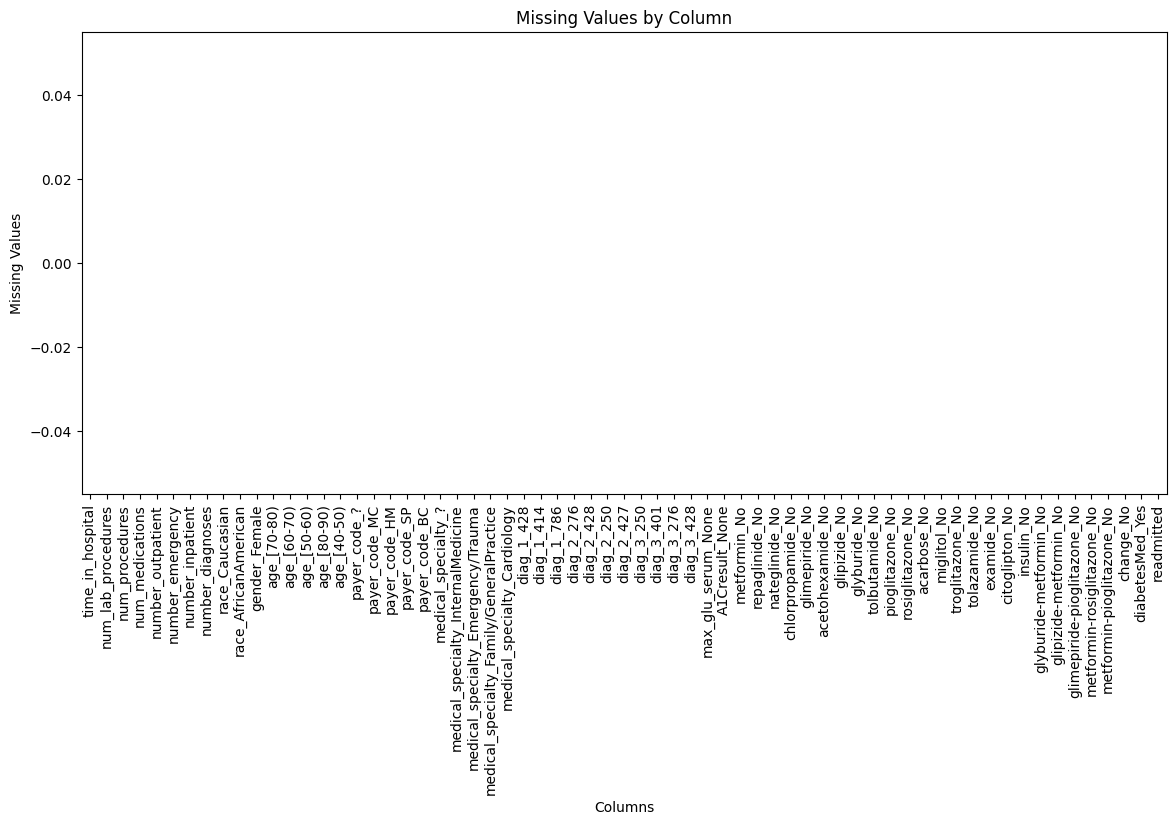

In [30]:
# Creating missing values chart
plt.figure(figsize=(14, 6))
sns.barplot(x=missing_values.index, y=missing_values.values)
plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Missing Values")
plt.xticks(rotation=90)
plt.show()

**3: EDA**

In [31]:
# Check summary statistics
df.describe()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted
count,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000
mean,4.395640,42.96012,1.341080,15.988440,0.365920,0.203280,0.64300,7.420160,0.456400
std,2.991165,19.76881,1.705398,8.107743,1.224419,0.982973,1.26286,1.940932,0.498105
min,1.000000,1.00000,0.000000,1.000000,0.000000,0.000000,0.00000,1.000000,0.000000
25%,2.000000,31.00000,0.000000,10.000000,0.000000,0.000000,0.00000,6.000000,0.000000
50%,4.000000,44.00000,1.000000,15.000000,0.000000,0.000000,0.00000,8.000000,0.000000
75%,6.000000,57.00000,2.000000,20.000000,0.000000,0.000000,1.00000,9.000000,1.000000
max,14.000000,126.00000,6.000000,81.000000,36.000000,64.000000,21.00000,16.000000,1.000000


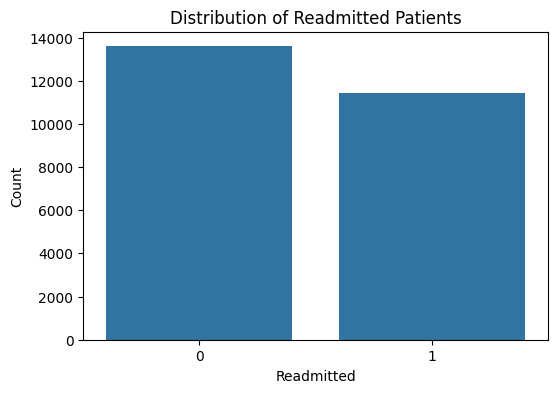

In [32]:
# Create target variable distribution chart
plt.figure(figsize=(6, 4))
sns.countplot(x="readmitted", data=df)
plt.title("Distribution of Readmitted Patients")
plt.xlabel("Readmitted")
plt.ylabel("Count")
plt.show()

# This chart shows how many patients were readmitted and not readmitted

In [33]:
# Numerical columns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

numerical_columns

Index(['time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'number_diagnoses', 'readmitted'],
      dtype='object')

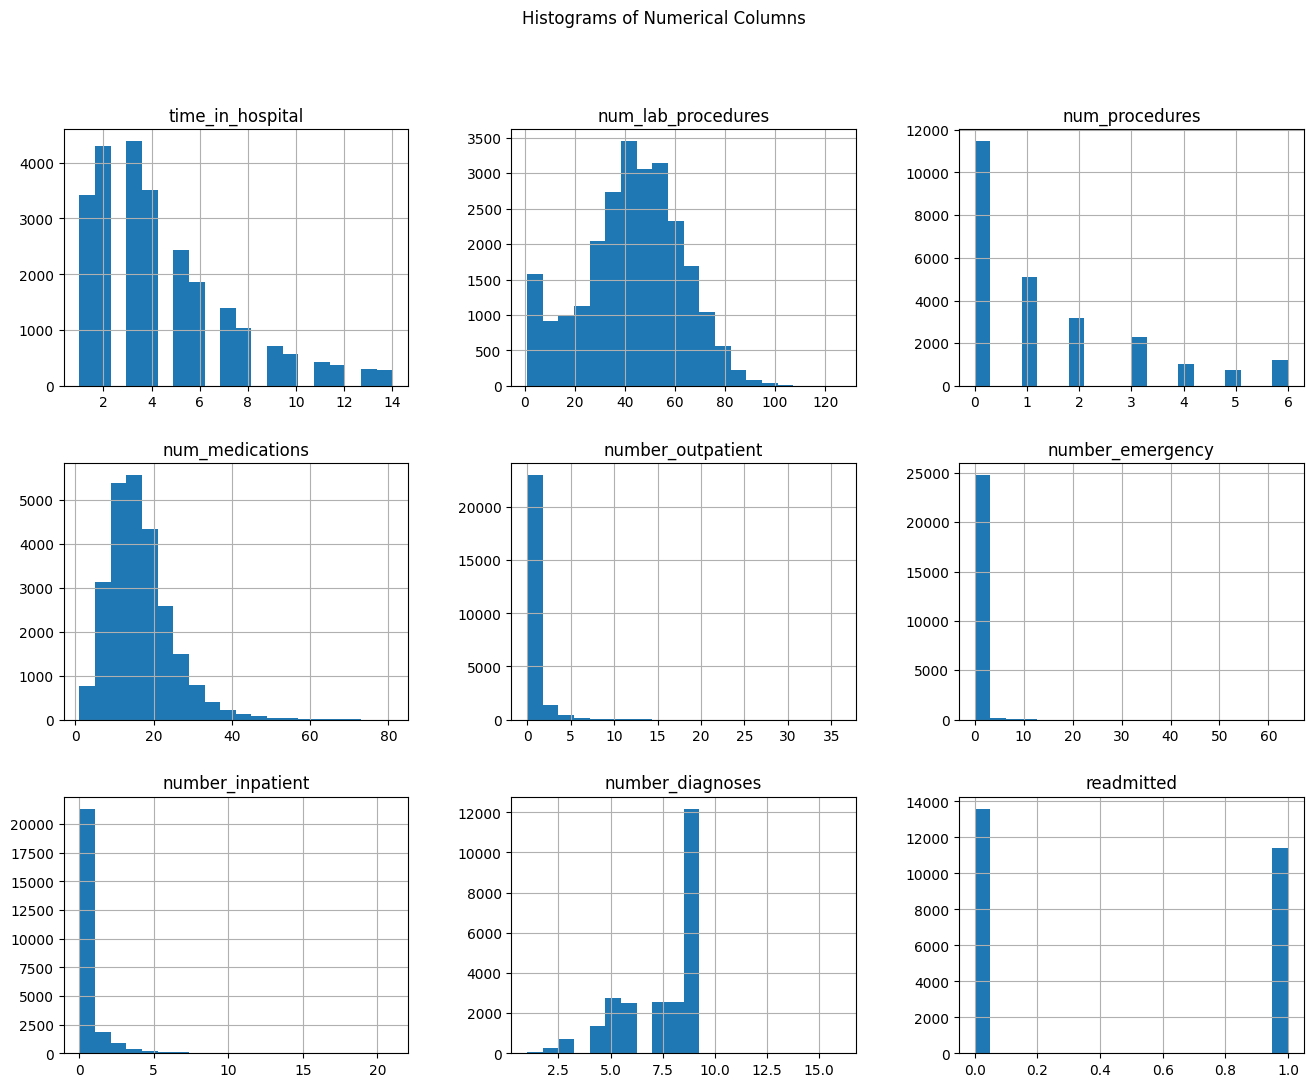

In [34]:
# Histograms for numerical columns
df[numerical_columns].hist(figsize=(16, 12), bins=20)
plt.suptitle("Histograms of Numerical Columns")
plt.show()



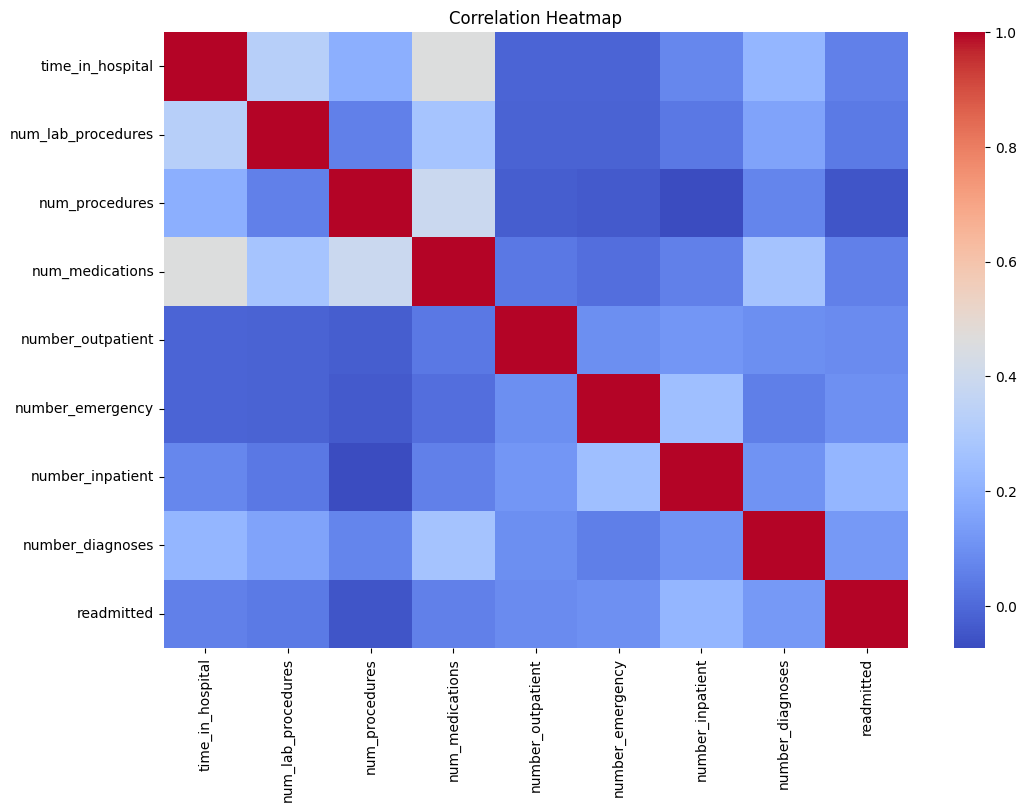

In [35]:
# Correlation table
correlation = df[numerical_columns].corr()

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# This chart shows relationships between numerical columns

In [36]:
# Find numerical features most related to readmitted
target_correlation = correlation["readmitted"].abs().sort_values(ascending=False)

top_features = target_correlation.drop("readmitted").head(5).index

top_features

Index(['number_inpatient', 'number_diagnoses', 'number_emergency',
       'number_outpatient', 'time_in_hospital'],
      dtype='object')

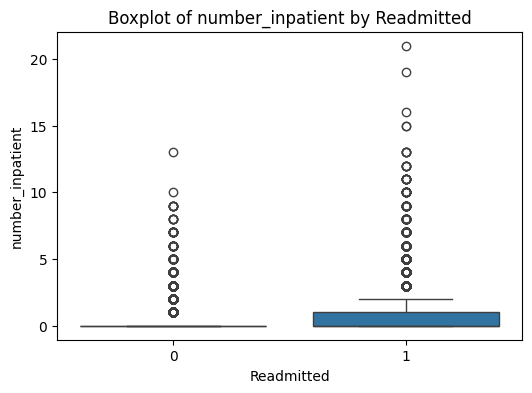

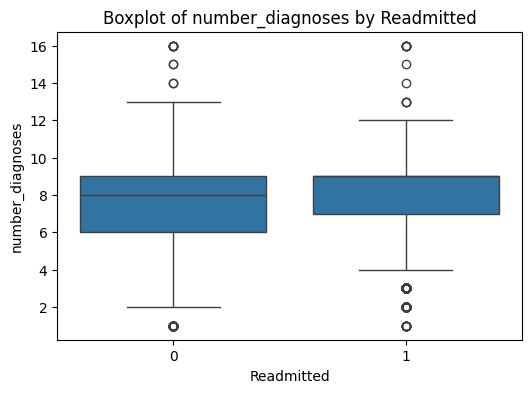

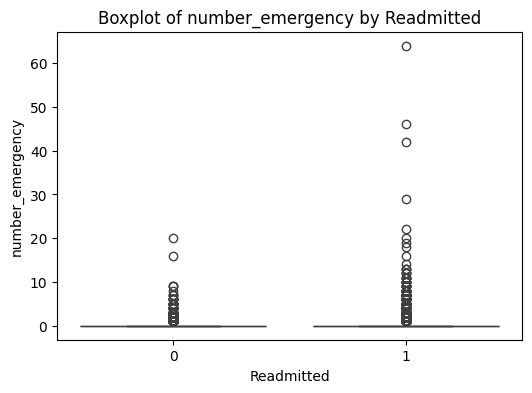

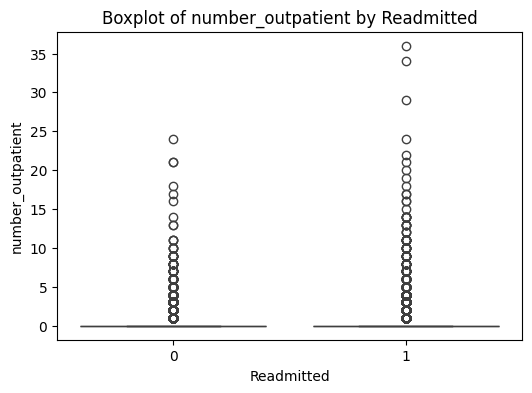

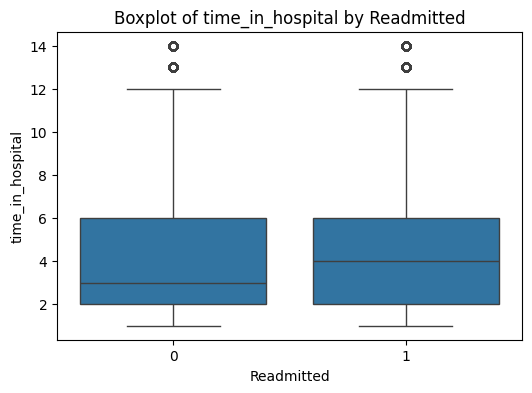

In [37]:
# Boxplots for top numerical features
for column in top_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="readmitted", y=column, data=df)
    plt.title("Boxplot of " + column + " by Readmitted")
    plt.xlabel("Readmitted")
    plt.ylabel(column)
    plt.show()

    # This boxplot compares the numerical feature between readmitted groups

In [38]:
# Target percentage
df["readmitted"].value_counts(normalize=True) * 100

,proportion
readmitted,
0,54.36
1,45.64


In [39]:
# Numerical columns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

# Removing target column from numerical columns
numerical_columns = numerical_columns.drop("readmitted")

# Comparing average values by readmission status
df.groupby("readmitted")[numerical_columns].mean()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
readmitted,,,,,,,,
0,4.237822,42.233996,1.419132,15.569610,0.268212,0.112656,0.392494,7.200662
1,4.583611,43.824978,1.248116,16.487292,0.482296,0.311218,0.941367,7.681595


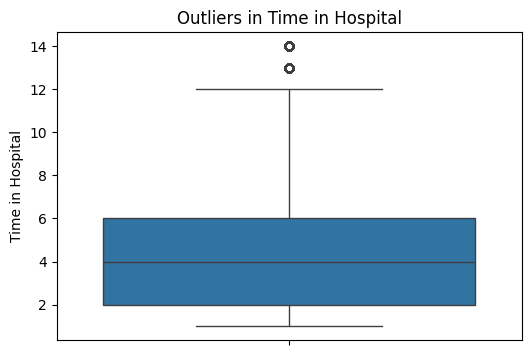

In [40]:
# Boxplot for hospital stay
plt.figure(figsize=(6, 4))
sns.boxplot(y=df["time_in_hospital"])
plt.title("Outliers in Time in Hospital")
plt.ylabel("Time in Hospital")
plt.show()

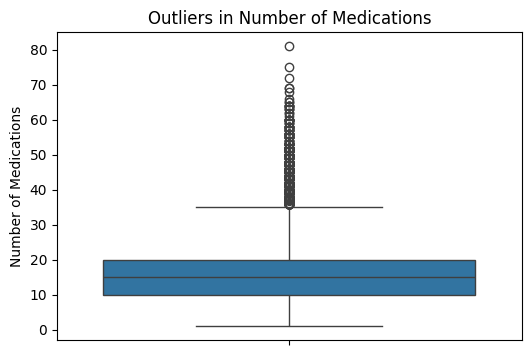

In [41]:
# Boxplot for number of medications
plt.figure(figsize=(6, 4))
sns.boxplot(y=df["num_medications"])
plt.title("Outliers in Number of Medications")
plt.ylabel("Number of Medications")
plt.show()

**4. Feature Enginnering**

In [42]:
# Utilization from previous hospital visits
df["utilization_score"] = df["number_inpatient"] + df["number_outpatient"] + df["number_emergency"]

In [43]:
# Total procedure activity
df["procedure_intensity"] = df["num_lab_procedures"] + df["num_procedures"]

In [44]:
# Medication load for each patient
df["medication_burden"] = df["num_medications"]

In [45]:
# Diagnosis count for patient complexity
df["chronic_complexity"] = df["number_diagnoses"]

In [46]:
# Lab procedures per hospital day
df["lab_procedures_per_day"] = df["num_lab_procedures"] / df["time_in_hospital"]

In [47]:
# Medications per hospital day
df["medications_per_day"] = df["num_medications"] / df["time_in_hospital"]

In [48]:
# Medication load compared with diagnosis count
df["medications_per_diagnosis"] = df["num_medications"] / df["number_diagnoses"]

In [49]:
# Utilization compared with diagnosis count
df["utilization_per_diagnosis"] = df["utilization_score"] / df["number_diagnoses"]

In [51]:
df[[
    "utilization_score",
    "procedure_intensity",
    "medication_burden",
    "chronic_complexity",
    "lab_procedures_per_day",
    "medications_per_day",
    "medications_per_diagnosis",
    "utilization_per_diagnosis"
]].head()

,utilization_score,procedure_intensity,medication_burden,chronic_complexity,lab_procedures_per_day,medications_per_day,medications_per_diagnosis,utilization_per_diagnosis
0,0,41,11,6,2.928571,0.785714,1.833333,0.000000
1,1,30,12,9,15.000000,6.000000,1.333333,0.111111
2,3,66,22,9,13.200000,4.400000,2.444444,0.333333
3,0,63,8,8,21.000000,2.666667,1.000000,0.000000
4,1,40,6,9,8.000000,1.200000,0.666667,0.111111


**5: Train/Test Split**

In [53]:
# Import train_test_split
from sklearn.model_selection import train_test_split

In [54]:
# Separate input features
X = df.drop("readmitted", axis=1)

# Separate target variable
y = df["readmitted"]

In [55]:
#Data split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [56]:
X_train.shape

(20000, 72)

In [57]:
X_test.shape

(5000, 72)

In [58]:
y_train.shape

(20000,)

In [59]:
y_test.shape

(5000,)

**6: MODEL**

In [61]:
#  Random Forest model
rf_model = RandomForestClassifier(random_state=42)

In [64]:
# Training model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [65]:
# Using the testing data
y_pred = rf_model.predict(X_test)

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Calculate precision
precision = precision_score(y_test, y_pred)

# Calculate recall
recall = recall_score(y_test, y_pred)

# Calculate F1 score
f1 = f1_score(y_test, y_pred)

In [ ]:
# Model score

# Using the testing data (re-run from aLW7vgHqy3dt)
y_pred = rf_model.predict(X_test)

# Calculate accuracy, precision, recall, F1 score (re-run from iCSY9lqPy2JO)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

model_scores = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Score": [accuracy, precision, recall, f1]
})


model_scores

In [67]:
# Confusion matrix
confusion_matrix_result = confusion_matrix(y_test, y_pred)

confusion_matrix_result

array([[1984,  747],
       [1197, 1072]])

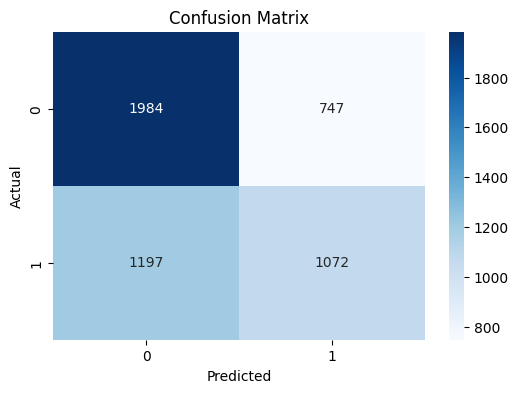

In [68]:
# Plot the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix_result, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**7: Cross Validation**

In [70]:
# Import StratifiedKFold for balanced cross validation
from sklearn.model_selection import StratifiedKFold

# Import cross_val_score to calculate scores for each fold
from sklearn.model_selection import cross_val_score

In [71]:
# 5-fold stratified cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [73]:
# Cross validation using the Random Forest model
cv_scores = cross_val_score(rf_model, X, y, cv=cv, scoring="accuracy")

In [74]:
cv_scores = cross_val_score(rf_model, X, y, cv=cv, scoring="accuracy")

In [75]:
cv_scores

array([0.6208, 0.6332, 0.6148, 0.6194, 0.617 ])

In [76]:
cv_scores.mean()

np.float64(0.62104)

In [77]:
cv_scores.std()

np.float64(0.006416728138233686)

**8: Hyperparameter Tuning**

In [89]:
# Import RandomizedSearchCV for random hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# Import Random Forest classifier
from sklearn.ensemble import RandomForestClassifier

In [78]:
# Set up the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

In [79]:
# Set the hyperparameter values to test
param_grid = {
    "n_estimators": [50, 100, 150, 200, 300],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [84]:
# Import RandomizedSearchCV for random hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42
)

In [86]:
# Run the random search on the training data
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20,
                   param_distributions={'max_depth': [5, 10, 15, 20, None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 150, 200,
                                                         300]},
                   random_state=42, scoring='accuracy')

In [87]:
# Display the best hyperparameters
random_search.best_params_

{'n_estimators': 100,
 'min_samples_split': 10,
 'min_samples_leaf': 4,
 'max_depth': 10}

In [88]:
# Display the best cross validation score
random_search.best_score_

np.float64(0.62845)

**9: Final Model**

In [90]:
# Get the best parameters from RandomizedSearchCV
best_parameters = random_search.best_params_

# Display the best parameters
best_parameters

{'n_estimators': 100,
 'min_samples_split': 10,
 'min_samples_leaf': 4,
 'max_depth': 10}

In [91]:
# Build the final Random Forest model using the best parameters
final_rf_model = RandomForestClassifier(
    **best_parameters,
    random_state=42
)

In [93]:
# Train the final model on the training data
final_rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=4, min_samples_split=10,
                       random_state=42)

In [94]:
# Make predictions on the test data
final_predictions = final_rf_model.predict(X_test)

In [95]:
# Get prediction probabilities for ROC AUC
final_probabilities = final_rf_model.predict_proba(X_test)[:, 1]

In [99]:
# Import roc_auc_score
from sklearn.metrics import roc_auc_score

# Calculate accuracy
final_accuracy = accuracy_score(y_test, final_predictions)

# Calculate precision
final_precision = precision_score(y_test, final_predictions)

# Calculate recall
final_recall = recall_score(y_test, final_predictions)

# Calculate F1 score
final_f1 = f1_score(y_test, final_predictions)

# Calculate ROC AUC
final_roc_auc = roc_auc_score(y_test, final_probabilities)

In [100]:
# Put final model results into a table
final_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"],
    "Score": [final_accuracy, final_precision, final_recall, final_f1, final_roc_auc]
})

# Display final model results
final_results

,Metric,Score
0,Accuracy,0.623600
1,Precision,0.607679
2,Recall,0.481269
3,F1 Score,0.537137
4,ROC AUC,0.666733


In [101]:
# Calculate the confusion matrix
final_confusion_matrix = confusion_matrix(y_test, final_predictions)

# Display the confusion matrix values
final_confusion_matrix

array([[2026,  705],
       [1177, 1092]])

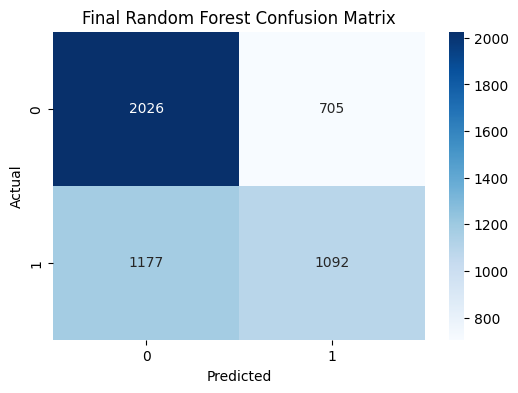

In [102]:
# Plot the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(final_confusion_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Final Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**10: Feature Importance**

In [103]:
# Get feature importance values from the final Random Forest model
feature_importance = final_rf_model.feature_importances_

# Get the feature names from the training data
feature_names = X_train.columns

In [104]:
# Put feature names and importance values into a table
feature_importance_table = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

In [105]:
# Sort features from highest importance to lowest importance
feature_importance_table = feature_importance_table.sort_values(
    by="Importance",
    ascending=False
)

In [106]:
# Select the top 20 most important features
top_20_features = feature_importance_table.head(20)

# Display the top 20 features table
top_20_features

,Feature,Importance
71,utilization_per_diagnosis,0.144104
64,utilization_score,0.112058
6,number_inpatient,0.098802
70,medications_per_diagnosis,0.044559
68,lab_procedures_per_day,0.043813
66,medication_burden,0.039407
1,num_lab_procedures,0.038647
3,num_medications,0.038096
69,medications_per_day,0.037796
65,procedure_intensity,0.037685


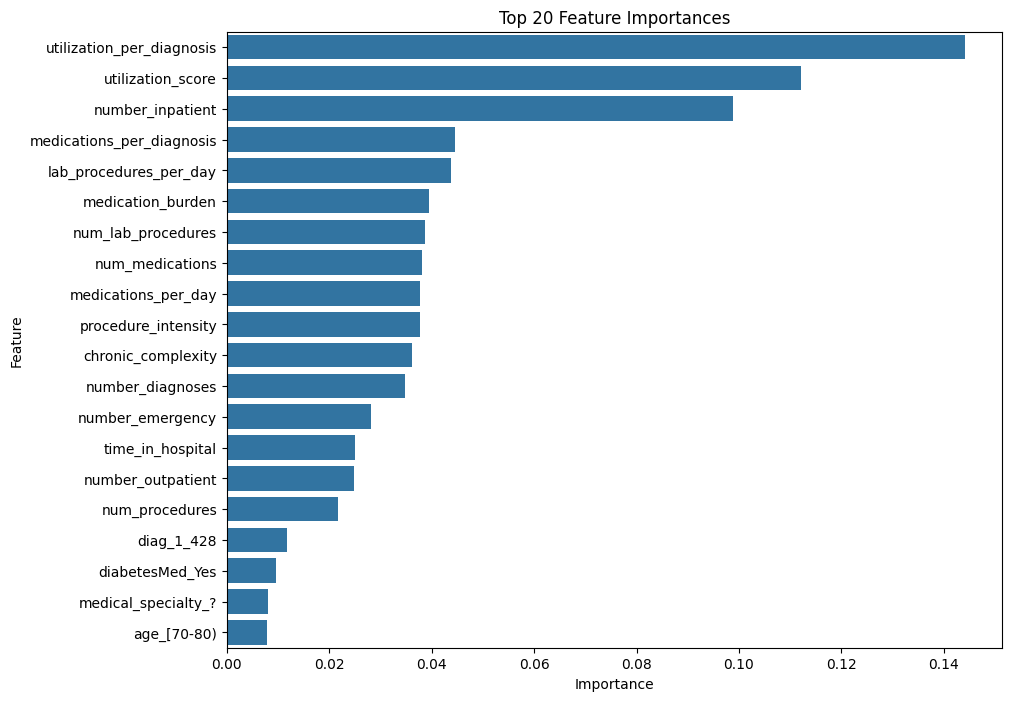

In [107]:
# Plot the top 20 feature importances
plt.figure(figsize=(10, 8))
sns.barplot(
    x="Importance",
    y="Feature",
    data=top_20_features
)
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()